# Train Test Splits, Cross Validation, and Linear Regression

![Lregressions.png](Assets/LinearRegr.png)

# Learning Objectives

- Explain the difference between over-fitting and under-fitting a model
- Describe Bias-variance tradeoffs
- Find the optimal training and test data set splits, cross-validation, and model complexity versus error
- Apply a linear regression model for supervised learning
- Apply Intel® Extension for Scikit-learn* to leverage underlying compute capabilities of hardware

# scikit-learn*

Frameworks provide structure that Data Scientists use to build code. Frameworks are more than just libraries, because in addition to callable code, frameworks influence how code is written.

A main virtue of using an optimized framework is that code runs faster. Code that runs faster is just generally more convenient but when we begin looking at applied data science and AI models, we can see more material benefits. Here you will see how optimization, particularly hyperparameter optimization can benefit more than just speed.

These exercises will demonstrate how to apply **the Intel® Extension for Scikit-learn*,** a seamless way to speed up your Scikit-learn application. The acceleration is achieved through the use of the Intel® oneAPI Data Analytics Library (oneDAL). Patching is the term used to extend scikit-learn with Intel optimizations and makes it a well-suited machine learning framework for dealing with real-life problems.

To get optimized versions of many Scikit-learn algorithms using a patch() approach consisting of adding these lines of code prior to importing sklearn:

- **from sklearnex import patch_sklearn**
- **patch_sklearn()**

## This exercise relies on installation of  Intel® Extension for Scikit-learn*

If you have not already done so, follow the instructions from Week 1 for instructions

## Introduction

We will be working with a data set based on [housing prices in Ames, Iowa](https://www.kaggle.com/c/house-prices-advanced-regression-techniques). It was compiled for educational use to be a modernized and expanded alternative to the well-known Boston Housing dataset. This version of the data set has had some missing values filled for convenience.

There are an extensive number of features, so they've been described in the table below.

### Predictor

* SalePrice: The property's sale price in dollars.


### Features

<table>
  <tbody>    
    <tr valign="top">
      <td valign="top">
        <ul>
          <li>MoSold: Month Sold</li>
          <li>YrSold: Year Sold</li><br>
          
          <li>SaleType: Type of sale</li>
          <li>SaleCondition: Condition of sale</li><br>

          <li>MSSubClass: The building class</li>
          <li>MSZoning: The general zoning classification</li><br>

          <li>Neighborhood: Physical locations within Ames city limits</li>
          <li>Street: Type of road access</li>
          <li>Alley: Type of alley access</li><br>

          <li>LotArea: Lot size in square feet</li>
          <li>LotConfig: Lot configuration</li>
          <li>LotFrontage: Linear feet of street connected to property</li>
          <li>LotShape: General shape of property</li><br>

          <li>LandSlope: Slope of property</li>
          <li>LandContour: Flatness of the property</li><br>

          <li>YearBuilt: Original construction date</li>
          <li>YearRemodAdd: Remodel date</li>
          <li>OverallQual: Overall material and finish quality</li>
          <li>OverallCond: Overall condition rating</li><br>

          <li>Utilities: Type of utilities available</li>
          <li>Foundation: Type of foundation</li>
          <li>Functional: Home functionality rating</li><br>

          <li>BldgType: Type of dwelling</li>
          <li>HouseStyle: Style of dwelling</li><br>
          
          <li>1stFlrSF: First Floor square feet</li>
          <li>2ndFlrSF: Second floor square feet</li>
          <li>LowQualFinSF: Low quality finished square feet (all floors)</li>
          <li>GrLivArea: Above grade (ground) living area square feet</li>
          <li>TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)</li><br>

          <li>Condition1: Proximity to main road or railroad</li>
          <li>Condition2: Proximity to main road or railroad (if a second is present)</li><br>
          
          <li>RoofStyle: Type of roof</li>
          <li>RoofMatl: Roof material</li><br>

          <li>ExterQual: Exterior material quality</li>
          <li>ExterCond: Present condition of the material on the exterior</li>
          <li>Exterior1st: Exterior covering on house</li>
          <li>Exterior2nd: Exterior covering on house (if more than one material)</li><br><br>
          
        </ul>
      </td>
      
      <td valign="top">
        <ul>
          <li>MasVnrType: Masonry veneer type</li>
          <li>MasVnrArea: Masonry veneer area in square feet</li><br>
          
          <li>WoodDeckSF: Wood deck area in square feet</li>
          <li>OpenPorchSF: Open porch area in square feet</li>
          <li>EnclosedPorch: Enclosed porch area in square feet</li>
          <li>3SsnPorch: Three season porch area in square feet</li>
          <li>ScreenPorch: Screen porch area in square feet</li><br>

          <li>PoolArea: Pool area in square feet</li>
          <li>PoolQC: Pool quality</li>
          <li>Fence: Fence quality</li>
          <li>PavedDrive: Paved driveway</li><br>

          <li>GarageType: Garage location</li>
          <li>GarageYrBlt: Year garage was built</li>
          <li>GarageFinish: Interior finish of the garage</li>
          <li>GarageCars: Size of garage in car capacity</li>
          <li>GarageArea: Size of garage in square feet</li>
          <li>GarageQual: Garage quality</li>
          <li>GarageCond: Garage condition</li><br>

          <li>Heating: Type of heating</li>
          <li>HeatingQC: Heating quality and condition</li>
          <li>CentralAir: Central air conditioning</li>
          <li>Electrical: Electrical system</li><br>
          
          <li>FullBath: Full bathrooms above grade</li>
          <li>HalfBath: Half baths above grade</li><br>
          
          <li>BedroomAbvGr: Number of bedrooms above basement level</li><br>
          
          <li>KitchenAbvGr: Number of kitchens</li>
          <li>KitchenQual: Kitchen quality</li><br>
          
          <li>Fireplaces: Number of fireplaces</li>
          <li>FireplaceQu: Fireplace quality</li><br>
          
          <li>MiscFeature: Miscellaneous feature not covered in other categories</li>
          <li>MiscVal: Value of miscellaneous feature</li><br>
          
          <li>BsmtQual: Height of the basement</li>
          <li>BsmtCond: General condition of the basement</li>
          <li>BsmtExposure: Walkout or garden level basement walls</li>
          <li>BsmtFinType1: Quality of basement finished area</li>
          <li>BsmtFinSF1: Type 1 finished square feet</li>
          <li>BsmtFinType2: Quality of second finished area (if present)</li>
          <li>BsmtFinSF2: Type 2 finished square feet</li>
          <li>BsmtUnfSF: Unfinished square feet of basement area</li>
          <li>BsmtFullBath: Basement full bathrooms</li>
          <li>BsmtHalfBath: Basement half bathrooms</li>
          <li>TotalBsmtSF: Total square feet of basement area</li>
        </ul>
      </td>
    </tr>
    
  </tbody>
</table>


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-learn-intelex


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 MB 6.0 MB/s eta 0:00:00


In [ ]:
from __future__ import print_function
import os
data_path = ['../data']

from sklearnex import patch_sklearn
patch_sklearn()

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Question 1

* Import the data using Pandas and examine the shape. There are 79 feature columns plus the predictor, the sale price (`SalePrice`).
* There are three different types: integers (`int64`), floats (`float64`), and strings (`object`, categoricals). Examine how many there are of each data type.

In [ ]:
import pandas as pd

# Load the dataset (assuming it's already mounted in your Drive)
data_path = '/content/drive/MyDrive/ML/data/Ames_Housing_Sales.csv'
df = pd.read_csv(data_path)

# 1. Display the shape of the dataset
print("Shape of the dataset:", df.shape)  # rows, columns

# 2. Display number of columns by data type
data_types = df.dtypes.value_counts()
print("\nNumber of columns by data type:")
print(data_types)


Shape of the dataset: (1379, 80)

Number of columns by data type:
object     43
float64    21
int64      16
Name: count, dtype: int64


## Question 2

As discussed in the lecture, a significant challenge, particularly when dealing with data that have many columns, is ensuring each column gets encoded correctly.

This is particularly true with data columns that are ordered categoricals (ordinals) vs unordered categoricals. Unordered categoricals should be one-hot encoded, however this can significantly increase the number of features and creates features that are highly correlated with each other.

Determine how many total features would be present, relative to what currently exists, if all string (object) features are one-hot encoded. Recall that the total number of one-hot encoded columns is `n-1`, where `n` is the number of categories.

In [ ]:
# Select the object (string) columns
categorical_cols = df.select_dtypes(include='object')


In [ ]:
# Calculate one-hot encoded feature count:
total_one_hot_features = 0
for col in categorical_cols.columns:
    unique_vals = df[col].nunique()
    # One-hot encoding creates (n - 1) new columns
    total_one_hot_features += (unique_vals - 1)

# Calculate existing number of features
original_feature_count = df.shape[1] - 1  # excluding the predictor 'SalePrice'

# Calculate final feature count after one-hot encoding
final_feature_count = original_feature_count - len(categorical_cols.columns) + total_one_hot_features

# Print results
print("Original number of features (excluding target):", original_feature_count)
print("Number of categorical (object) columns:", len(categorical_cols.columns))
print("Total one-hot encoded columns added:", total_one_hot_features)
print("Final number of features after one-hot encoding:", final_feature_count)

Original number of features (excluding target): 79
Number of categorical (object) columns: 43
Total one-hot encoded columns added: 204
Final number of features after one-hot encoding: 240


## Question 3

Let's create a new data set where all of the above categorical features will be one-hot encoded. We can fit this data and see how it affects the results.

* Used the dataframe `.copy()` method to create a completely separate copy of the dataframe for one-hot encoding
* On this new dataframe, one-hot encode each of the appropriate columns and add it back to the dataframe. Be sure to drop the original column.
* For the data that are not one-hot encoded, drop the columns that are string categoricals.

For the first step, numerically encoding the string categoricals, either Scikit-learn;s `LabelEncoder` or `DictVectorizer` can be used. However, the former is probably easier since it doesn't require specifying a numerical value for each category, and we are going to one-hot encode all of the numerical values anyway. (Can you think of a time when `DictVectorizer` might be preferred?)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Load the data
data_path = '/content/drive/MyDrive/ML/data/Ames_Housing_Sales.csv'
data = pd.read_csv(data_path)

# Select only object columns
cat_cols = data.select_dtypes(include='object')

# Filter out columns with only one unique value (no need to encode them)
num_ohc_cols = cat_cols.nunique()
num_ohc_cols = num_ohc_cols[num_ohc_cols > 1]

# Copy of the data
data_ohc = data.copy()

# The encoders
le = LabelEncoder()
ohc = OneHotEncoder(sparse_output=False, drop='first')

for col in num_ohc_cols.index:
    # Integer encode the string categories
    int_encoded = le.fit_transform(data_ohc[col])

    # Remove the original column from the dataframe
    data_ohc.drop(columns=col, inplace=True)

    # One-hot encode the data — returns a numpy array
    onehot_encoded = ohc.fit_transform(int_encoded.reshape(-1, 1))

    # Create unique column names
    categories = ohc.categories_[0][1:]  # skip first category (due to drop='first')
    new_col_names = [f"{col}_{cat}" for cat in categories]

    # Create the new dataframe
    onehot_df = pd.DataFrame(onehot_encoded, columns=new_col_names, index=data_ohc.index)

    # Append the new data to the dataframe
    data_ohc = pd.concat([data_ohc, onehot_df], axis=1)

# Final result
print("Shape after custom one-hot encoding:", data_ohc.shape)


Shape after custom one-hot encoding: (1379, 252)


In [ ]:
# Column difference is as calculated above
original_columns = data.shape[1]
new_columns = data_ohc.shape[1]
column_difference = new_columns - original_columns

print(f"Original number of columns: {original_columns}")
print(f"New number of columns after one-hot encoding: {new_columns}")
print(f"Column difference (extra columns added): {column_difference}")

Original number of columns: 80
New number of columns after one-hot encoding: 252
Column difference (extra columns added): 172


## Question 4

* Create train and test splits of both data sets. To ensure the data gets split the same way, use the same `random_state` in each of the two splits.
* For each data set, fit a basic linear regression model on the training data.
* Calculate the mean squared error on both the train and test sets for the respective models. Which model produces smaller error on the test data and why?

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Apply label encoding to categorical columns for the non-one-hot encoded data
label_encoder = LabelEncoder()

# Get the list of categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns

# Apply label encoding to each categorical column
for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

# Now, we can proceed with the train/test split and model fitting

# Split the data into train and test sets for the non-one-hot encoded data
X = data.drop(columns=['SalePrice'])  # Features
y = data['SalePrice']  # Target

# Split the data for training/testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the linear regression model
LR.fit(X_train, y_train)

# Make predictions
y_train_pred = LR.predict(X_train)
y_test_pred = LR.predict(X_test)

# Calculate MSE for the non-one-hot encoded data
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# Print MSE for non-one-hot encoded model
print("MSE on train data (non-one-hot encoded):", mse_train)
print("MSE on test data (non-one-hot encoded):", mse_test)

# Now, for the one-hot encoded data (as before)

X_ohc = data_ohc.drop(columns=['SalePrice'])  # Features for one-hot encoded data
# Split for data that has been one-hot encoded
X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc = train_test_split(X_ohc, y, test_size=0.2, random_state=42)

# Fit the model on data that has been one-hot encoded
LR.fit(X_train_ohc, y_train_ohc)

# Make predictions
y_train_pred_ohc = LR.predict(X_train_ohc)
y_test_pred_ohc = LR.predict(X_test_ohc)

# Calculate MSE for the one-hot encoded data
mse_train_ohc = mean_squared_error(y_train_ohc, y_train_pred_ohc)
mse_test_ohc = mean_squared_error(y_test_ohc, y_test_pred_ohc)

# Print MSE for one-hot encoded model
print("MSE on train data (one-hot encoded):", mse_train_ohc)
print("MSE on test data (one-hot encoded):", mse_test_ohc)


MSE on train data (non-one-hot encoded): 853930418.8161913
MSE on test data (non-one-hot encoded): 1491580051.9672463
MSE on train data (one-hot encoded): 352247070.61253864
MSE on test data (one-hot encoded): 3509403181.8295193


Note that the error values on the one-hot encoded data are very different for the train and test data. In particular, the errors on the test data are much higher. Based on the lecture, this is because the one-hot encoded model is overfitting the data. We will learn how to deal with issues like this in the next lesson.

## Question 5

For each of the data sets (one-hot encoded and not encoded):

* Scale the all the non-hot encoded values using one of the following: `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`.
* Compare the error calculated on the test sets

Be sure to calculate the skew (to decide if a transformation should be done) and fit the scaler on *ONLY* the training data, but then apply it to both the train and test data identically.

In [ ]:
# Mute the setting with a copy warnings
pd.options.mode.chained_assignment = None

# Scale the data
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "MaxAbsScaler": MaxAbsScaler()
}

# Prepare a dictionary to store results for comparison
results = {}

# Function to apply scaling, fit model and calculate MSE
def scale_and_evaluate(X_train, X_test, y_train, y_test, scaler_name):
    # Initialize the scaler
    scaler = scalers[scaler_name]

    # Fit the scaler on training data and transform both train and test sets
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fit the linear regression model on scaled data
    LR.fit(X_train_scaled, y_train)

    # Make predictions
    y_train_pred = LR.predict(X_train_scaled)
    y_test_pred = LR.predict(X_test_scaled)

    # Calculate MSE for train and test sets
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    # Store the results
    results[scaler_name] = {"train_mse": mse_train, "test_mse": mse_test}

# For data that has not been one-hot encoded, first apply label encoding
label_encoder = LabelEncoder()
categorical_cols = data.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns for the non-one-hot encoded data
for col in categorical_cols:
    data[col] = label_encoder.fit_transform(data[col])

# Split the data into train and test sets for the non-one-hot encoded data
X = data.drop(columns=['SalePrice'])  # Features
y = data['SalePrice']  # Target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale and evaluate for non-one-hot encoded data
for scaler_name in scalers.keys():
    scale_and_evaluate(X_train, X_test, y_train, y_test, scaler_name)

# Now, for the one-hot encoded data
X_ohc = data_ohc.drop(columns=['SalePrice'])  # Features for one-hot encoded data
X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc = train_test_split(X_ohc, y, test_size=0.2, random_state=42)

# Scale and evaluate for one-hot encoded data
for scaler_name in scalers.keys():
    scale_and_evaluate(X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc, scaler_name)

# Print out the results
print("Results for Non-One-Hot Encoded Data:")
for scaler_name in scalers.keys():
    print(f"{scaler_name} - Train MSE: {results[scaler_name]['train_mse']}, Test MSE: {results[scaler_name]['test_mse']}")

print("\nResults for One-Hot Encoded Data:")
for scaler_name in scalers.keys():
    print(f"{scaler_name} - Train MSE: {results[scaler_name]['train_mse']}, Test MSE: {results[scaler_name]['test_mse']}")

Results for Non-One-Hot Encoded Data:
StandardScaler - Train MSE: 352247070.6084864, Test MSE: 3166723003.931422
MinMaxScaler - Train MSE: 352247070.60848653, Test MSE: 3330808633.5244966
MaxAbsScaler - Train MSE: 352247070.60848635, Test MSE: 3509460054.3626084

Results for One-Hot Encoded Data:
StandardScaler - Train MSE: 352247070.6084864, Test MSE: 3166723003.931422
MinMaxScaler - Train MSE: 352247070.60848653, Test MSE: 3330808633.5244966
MaxAbsScaler - Train MSE: 352247070.60848635, Test MSE: 3509460054.3626084


## Question 6

Plot predictions vs actual for one of the models.

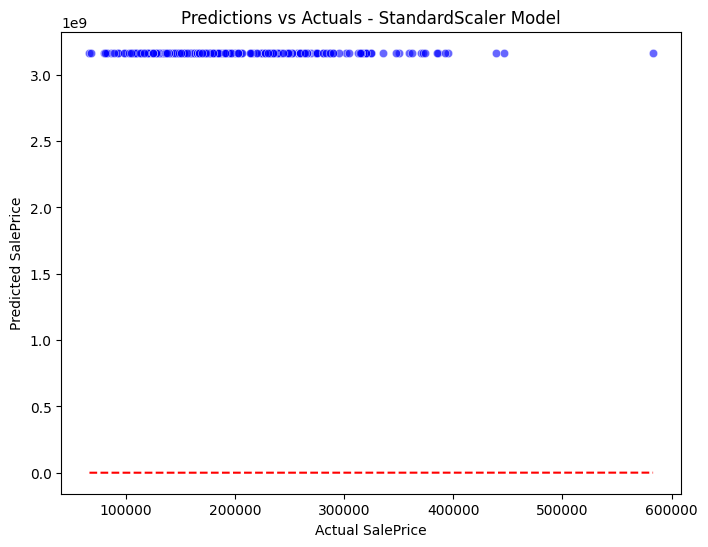

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Select the scaler to plot (StandardScaler for this example)
scaler_name = "StandardScaler"

# Use the model that was trained with StandardScaler
y_test_pred_standard = results[scaler_name]['test_mse']  # Replace this line with actual predictions

# Create the plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred_standard, color='blue', alpha=0.6)

# Add labels and title
plt.title('Predictions vs Actuals - StandardScaler Model')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')

# Add a line for perfect predictions (y = x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

# Show the plot
plt.show()
